In [1]:
!pip install -q kagglehub

In [2]:
# 2. Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import kagglehub


In [3]:
# 3. Descarga del dataset desde Kaggle con kagglehub
# kagglehub descarga el dataset sin pasos manuales y hace el notebook reproducible.

path = kagglehub.dataset_download('mikoajkolman/pokemon-images-first-generation17000-files')

# Carpeta raiz que contiene las subcarpetas (una por Pokemon)
DATA_DIR = None
for root, dirs, files in os.walk(path):
    if len(dirs) > 100:
        DATA_DIR = root
        break


Using Colab cache for faster access to the 'pokemon-images-first-generation17000-files' dataset.


Clases: 143 | Imagenes: 16482 | Promedio por clase: 115 (min 45, max 214)


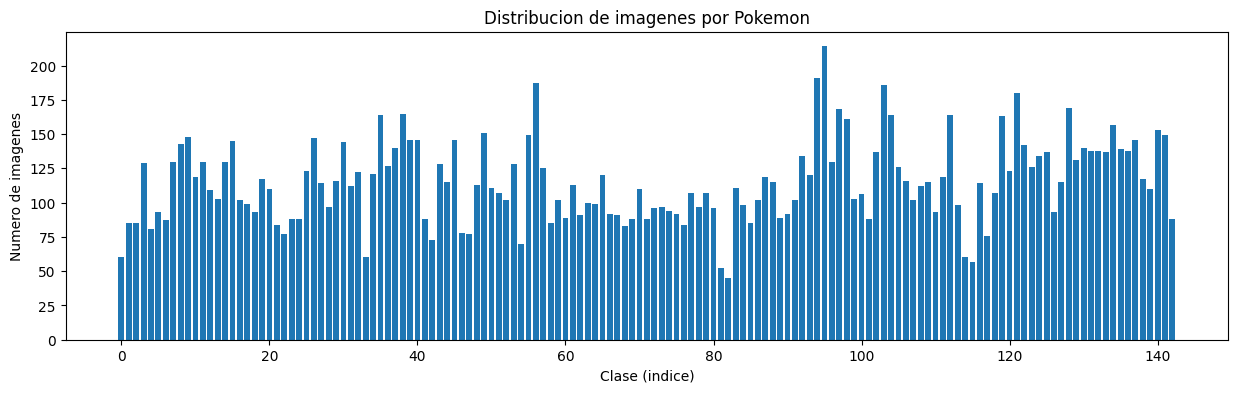

In [4]:
# 4. Exploracion del dataset: numero de imagenes por clase
class_names = sorted(os.listdir(DATA_DIR))
counts = {}
for c in class_names:
    folder = os.path.join(DATA_DIR, c)
    if os.path.isdir(folder):
        counts[c] = len([f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f'Clases: {len(counts)} | Imagenes: {sum(counts.values())} | '
      f'Promedio por clase: {sum(counts.values()) / len(counts):.0f} '
      f'(min {min(counts.values())}, max {max(counts.values())})')

plt.figure(figsize=(15, 4))
plt.bar(range(len(counts)), list(counts.values()))
plt.xlabel('Clase (indice)')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de imagenes por Pokemon')
plt.show()


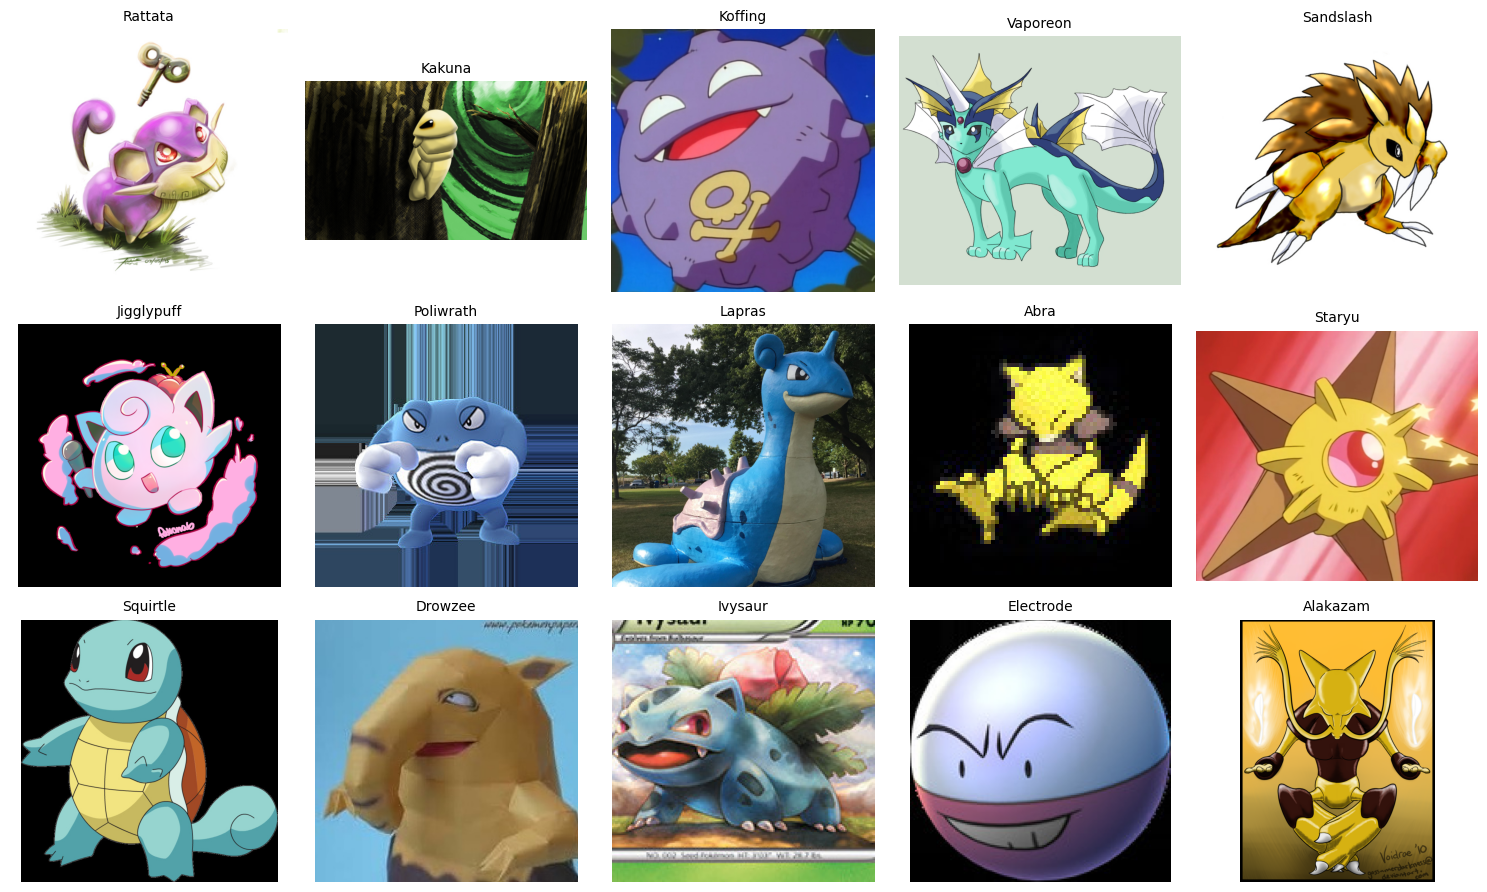

In [5]:
# 5. Visualizacion de imagenes de ejemplo
import random
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_classes = random.sample(class_names, 15)
for ax, cls in zip(axes.flat, sample_classes):
    folder = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if img_files:
        img_path = os.path.join(folder, random.choice(img_files))
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(cls, fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# 6. Preparacion del dataset con ImageDataGenerator
# - Rescalado de pixeles a [0,1] (1./255)
# - Redimensionado a 128x128
# - Split 80/20 train/validation con validation_split
# - Data augmentation SOLO en entrenamiento

IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes


Found 13246 images belonging to 143 classes.
Found 3239 images belonging to 143 classes.


In [7]:
# 7. Construccion del modelo con Transfer Learning (MobileNetV2)
# Justificacion: MobileNetV2 preentrenada en ImageNet captura features visuales
# generales (bordes, texturas, formas) que se reutilizan para reconocer Pokemon.

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelamos la base para transfer learning puro

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 143)            │        36,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,671 (10.00 MB)

 Trainable params: 364,687 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# 8. Callbacks: ModelCheckpoint, EarlyStopping y ReduceLROnPlateau
callbacks = [
    ModelCheckpoint(
        'pokemon_cnn_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [9]:
# 9. Entrenamiento del modelo (fase 1: transfer learning con base congelada)
EPOCHS = 15

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
 33/414 ━━━━━━━━━━━━━━━━━━━━ 3:55 618ms/step - accuracy: 0.0233 - loss: 5.4670

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.1097 - loss: 4.4205
Epoch 1: val_accuracy improved from None to 0.59555, saving model to pokemon_cnn_best.h5



Epoch 1: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 368s 838ms/step - accuracy: 0.2116 - loss: 3.6489 - val_accuracy: 0.5956 - val_loss: 1.7634 - learning_rate: 0.0010
Epoch 2/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.4521 - loss: 2.2044
Epoch 2: val_accuracy improved from 0.59555 to 0.71380, saving model to pokemon_cnn_best.h5



Epoch 2: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 206s 499ms/step - accuracy: 0.4799 - loss: 2.0810 - val_accuracy: 0.7138 - val_loss: 1.1889 - learning_rate: 0.0010
Epoch 3/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.5546 - loss: 1.7324
Epoch 3: val_accuracy improved from 0.71380 to 0.72831, saving model to pokemon_cnn_best.h5


...


Epoch 4: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 206s 498ms/step - accuracy: 0.5975 - loss: 1.5288 - val_accuracy: 0.7487 - val_loss: 0.9859 - learning_rate: 0.0010
Epoch 5/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6365 - loss: 1.3780
Epoch 5: val_accuracy improved from 0.74869 to 0.75672, saving model to pokemon_cnn_best.h5



Epoch 5: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 214s 516ms/step - accuracy: 0.6277 - loss: 1.4052 - val_accuracy: 0.7567 - val_loss: 0.9246 - learning_rate: 0.0010
Epoch 6/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.6462 - loss: 1.2931
Epoch 6: val_accuracy did not improve from 0.75672
414/414 ━━━━━━━━━━━━━━━━━━━━ 210s 508ms/step - accuracy: 0.6414 - loss: 1.3272 - val_accuracy: 0.7555 - val_loss: 0.9290 - learning_rate: 0.0010
Epoch 7/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.6672 - loss: 1.2337
Epoch 7: val_accuracy improved from 0.75672 to 0.77061, saving model to pokemon_cnn_best.h5



Epoch 7: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 259s 502ms/step - accuracy: 0.6563 - loss: 1.2689 - val_accuracy: 0.7706 - val_loss: 0.8727 - learning_rate: 0.0010
Epoch 8/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6759 - loss: 1.1875
Epoch 8: val_accuracy improved from 0.77061 to 0.77987, saving model to pokemon_cnn_best.h5



Epoch 8: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 214s 518ms/step - accuracy: 0.6721 - loss: 1.2089 - val_accuracy: 0.7799 - val_loss: 0.8452 - learning_rate: 0.0010
Epoch 9/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6811 - loss: 1.1575
Epoch 9: val_accuracy did not improve from 0.77987
414/414 ━━━━━━━━━━━━━━━━━━━━ 220s 531ms/step - accuracy: 0.6806 - loss: 1.1671 - val_accuracy: 0.7799 - val_loss: 0.8571 - learning_rate: 0.0010
Epoch 10/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6982 - loss: 1.1017
Epoch 10: val_accuracy improved from 0.77987 to 0.79932, saving model to pokemon_cnn_best.h5



Epoch 10: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 217s 525ms/step - accuracy: 0.6849 - loss: 1.1423 - val_accuracy: 0.7993 - val_loss: 0.7832 - learning_rate: 0.0010
Epoch 11/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7089 - loss: 1.0544
Epoch 11: val_accuracy did not improve from 0.79932
414/414 ━━━━━━━━━━━━━━━━━━━━ 218s 527ms/step - accuracy: 0.6971 - loss: 1.0999 - val_accuracy: 0.7805 - val_loss: 0.8447 - learning_rate: 0.0010
Epoch 12/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.6963 - loss: 1.0805
Epoch 12: val_accuracy did not improve from 0.79932

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
414/414 ━━━━━━━━━━━━━━━━━━━━ 213s 515ms/step - accuracy: 0.6916 - loss: 1.1059 - val_accuracy: 0.7854 - val_loss: 0.8044 - learning_rate: 0.0010
Epoch 13/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.7283 - loss: 0.9757
Epoch 13: val_accuracy did not improve from 0.79932
414/414 

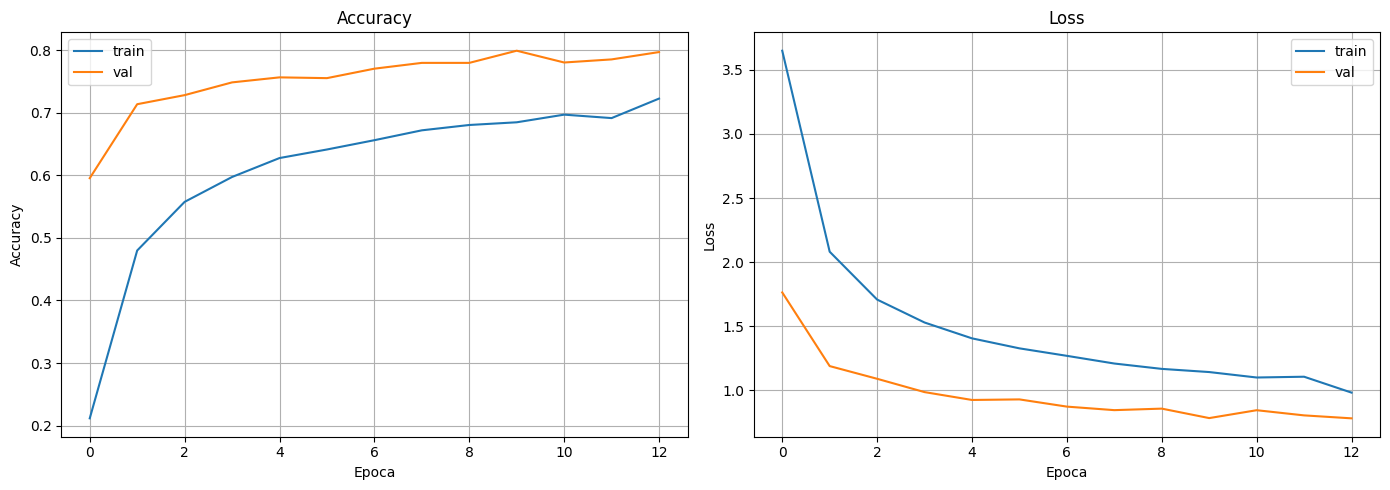

In [10]:
# 10. Graficas de loss y accuracy (entrenamiento vs validacion)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
# 11. Fine-tuning (fase 2): descongelamos las ultimas capas de MobileNetV2
# para ajustar mejor el modelo a Pokemon.
base_model.trainable = True
# Solo descongelamos las ultimas 30 capas
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # LR muy bajo para no destruir los pesos
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.4895 - loss: 2.0497
Epoch 1: val_accuracy improved from 0.79932 to 0.81136, saving model to pokemon_cnn_best.h5



Epoch 1: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 253s 565ms/step - accuracy: 0.5131 - loss: 1.9290 - val_accuracy: 0.8114 - val_loss: 0.7308 - learning_rate: 1.0000e-05
Epoch 2/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5730 - loss: 1.6215
Epoch 2: val_accuracy did not improve from 0.81136
414/414 ━━━━━━━━━━━━━━━━━━━━ 200s 483ms/step - accuracy: 0.5850 - loss: 1.5588 - val_accuracy: 0.8095 - val_loss: 0.7138 - learning_rate: 1.0000e-05
Epoch 3/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6338 - loss: 1.3702
Epoch 3: val_accuracy did not improve from 0.81136
414/414 ━━━━━━━━━━━━━━━━━━━━ 195s 470ms/step - accuracy: 0.6361 - loss: 1.3595 - val_accuracy: 0.8114 - val_loss: 0.7099 - learning_rate: 1.0000e-05
Epoch 4/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6613 - loss: 1.2460
Epoch 4: val_accuracy did not improve from 0.81136
414/414 ━━━━━━━━━━━━━━━━━━━━ 194s 469ms/step - accuracy: 0.6629 - loss: 1.2373 - 

In [12]:
# 12. Evaluacion final con classification_report y matriz de confusion

val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

print('Accuracy global:', np.mean(y_pred == y_true))
print()
print('Classification report:')
print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))

102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 447ms/step
Accuracy global: 0.8113615313368323

Classification report:
              precision    recall  f1-score   support

        Abra       0.80      0.33      0.47        12
  Aerodactyl       0.77      0.59      0.67        17
    Alakazam       0.60      0.88      0.71        17
       Arbok       0.88      0.92      0.90        25
    Arcanine       0.67      0.75      0.71        16
    Articuno       0.80      0.89      0.84        18
    Beedrill       0.93      0.82      0.88        17
  Bellsprout       0.92      0.92      0.92        26
   Blastoise       0.95      0.75      0.84        28
   Bulbasaur       0.83      1.00      0.91        29
  Butterfree       0.91      0.91      0.91        23
    Caterpie       0.93      0.96      0.94        26
     Chansey       1.00      0.71      0.83        21
   Charizard       0.79      0.75      0.77        20
  Charmander       0.72      1.00      0.84        26
  Charmeleon       0.83      0.

Shape de la matriz de confusion: (143, 143)

Top 10 Pokemon que mas se confunden:
  Pinsir: 13 errores de 26 muestras
  Electabuzz: 13 errores de 24 muestras
  Farfetchd: 12 errores de 25 muestras
  Starmie: 12 errores de 28 muestras
  Rapidash: 12 errores de 25 muestras
  Pidgey: 12 errores de 38 muestras
  Pidgeotto: 12 errores de 24 muestras
  Marowak: 11 errores de 18 muestras
  Primeape: 11 errores de 27 muestras
  Kadabra: 11 errores de 17 muestras

Top 15 confusiones (real -> predicho):
  Starmie        -> Staryu         9 veces
  Rapidash       -> Ponyta         9 veces
  Pidgeotto      -> Pidgeot        7 veces
  Wartortle      -> Squirtle       5 veces
  Electrode      -> Voltorb        5 veces
  Poliwhirl      -> Poliwrath      5 veces
  Electabuzz     -> Alakazam       4 veces
  Jolteon        -> Zapdos         4 veces
  Blastoise      -> Nidoqueen      4 veces
  Poliwrath      -> Poliwhirl      4 veces
  Pidgeot        -> Pidgeotto      4 veces
  Lapras         -> Golduck 

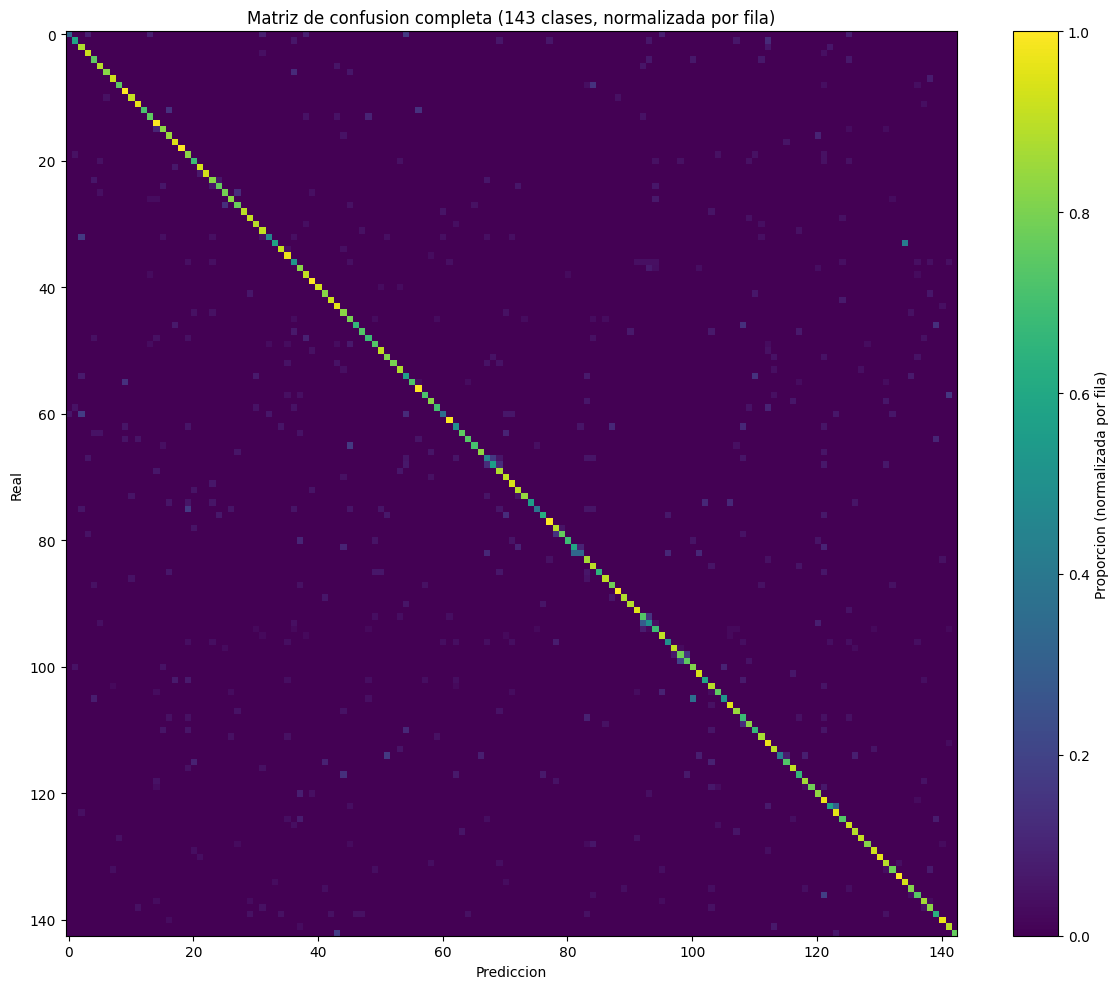

In [13]:
# 13. Matriz de confusion
cm = confusion_matrix(y_true, y_pred)
print('Shape de la matriz de confusion:', cm.shape)

# (a) Top 10 clases con mas errores (falsos negativos)
errors_per_class = cm.sum(axis=1) - np.diag(cm)
top_confused = np.argsort(errors_per_class)[-10:][::-1]
print('\nTop 10 Pokemon que mas se confunden:')
for idx in top_confused:
    print(f'  {class_labels[idx]}: {errors_per_class[idx]} errores de {cm[idx].sum()} muestras')

# (b) Pares (real -> predicho) mas confundidos, fuera de la diagonal
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_order = np.argsort(cm_off, axis=None)[::-1]
print('\nTop 15 confusiones (real -> predicho):')
shown = 0
for flat in flat_order:
    i, j = np.unravel_index(flat, cm_off.shape)
    if cm_off[i, j] == 0 or shown >= 15:
        break
    print(f'  {class_labels[i]:<14} -> {class_labels[j]:<14} {cm_off[i, j]} veces')
    shown += 1

# (c) Matriz de confusion COMPLETA (143x143) normalizada por fila, como imagen
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, cmap='viridis', aspect='auto')
plt.colorbar(label='Proporcion (normalizada por fila)')
plt.title('Matriz de confusion completa (143 clases, normalizada por fila)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 14. Guardado del modelo final en formato .h5

model.save('pokemon_cnn_final.h5')
print('Modelo guardado en pokemon_cnn_final.h5')

# Verificamos que se puede cargar
from tensorflow.keras.models import load_model
loaded_model = load_model('pokemon_cnn_final.h5')
print('Modelo cargado correctamente. Capas:', len(loaded_model.layers))

Modelo guardado en pokemon_cnn_final.h5


Modelo cargado correctamente. Capas: 7


Imagen: /kaggle/input/pokemon-images-first-generation17000-files/pokemon/Ponyta/c5faf69addf241debee3816c35f294d9.jpg
  Ponyta: 57.44%
  Rattata: 12.20%
  Victreebel: 5.92%


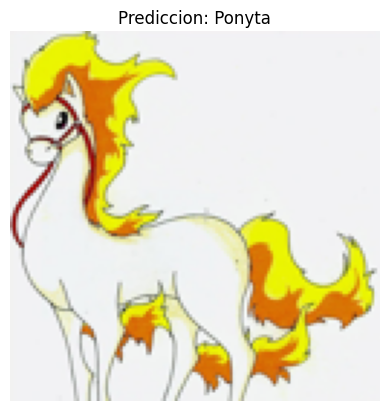

In [15]:
# 15. Prueba: prediccion sobre una imagen individual
# Demostracion de uso del modelo entrenado.

def predict_pokemon(img_path, model, class_labels, img_size=128):
    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    top3 = np.argsort(probs)[-3:][::-1]
    print(f'Imagen: {img_path}')
    for idx in top3:
        print(f'  {class_labels[idx]}: {probs[idx]*100:.2f}%')
    plt.imshow(img)
    plt.title(f'Prediccion: {class_labels[top3[0]]}')
    plt.axis('off')
    plt.show()

# Prueba con una imagen aleatoria del dataset
sample_class = random.choice(class_names)
sample_folder = os.path.join(DATA_DIR, sample_class)
sample_imgs = [f for f in os.listdir(sample_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
sample_path = os.path.join(sample_folder, random.choice(sample_imgs))
predict_pokemon(sample_path, model, class_labels)

In [16]:
# ============================================================
# MODELO 2 - EfficientNetB0 (mejora sobre el baseline)
# ============================================================
# Idea / articulo del estado del arte:
#   Tan & Le (2019) "EfficientNet: Rethinking Model Scaling for
#   Convolutional Neural Networks". ICML. arXiv:1905.11946
#   EfficientNet usa "compound scaling" (escala balanceada de profundidad,
#   anchura y resolucion) y supera a MobileNetV2 en ImageNet con un costo
#   computacional similar, por lo que se espera que mejore el accuracy.
#
# Cambios respecto al Modelo 1:
#   1. Backbone mas potente: EfficientNetB0 en vez de MobileNetV2.
#   2. Resolucion de entrada 224x224 (mas detalle, como sugiere el paper).
#   3. Preprocesado especifico de EfficientNet.

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

IMG_SIZE_2 = 224
BATCH_SIZE_2 = 32

train_datagen_2 = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)
val_datagen_2 = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    validation_split=0.2
)

train_gen_2 = train_datagen_2.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE_2, IMG_SIZE_2), batch_size=BATCH_SIZE_2,
    class_mode='categorical', subset='training', seed=42
)
val_gen_2 = val_datagen_2.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE_2, IMG_SIZE_2), batch_size=BATCH_SIZE_2,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

base_model_2 = EfficientNetB0(
    input_shape=(IMG_SIZE_2, IMG_SIZE_2, 3), include_top=False, weights='imagenet'
)
base_model_2.trainable = False

inputs_2 = tf.keras.Input(shape=(IMG_SIZE_2, IMG_SIZE_2, 3))
x = base_model_2(inputs_2, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs_2 = Dense(NUM_CLASSES, activation='softmax')(x)

model_2 = Model(inputs_2, outputs_2)
model_2.compile(optimizer=Adam(learning_rate=1e-3),
                loss='categorical_crossentropy', metrics=['accuracy'])
model_2.summary()

Found 13246 images belonging to 143 classes.
Found 3239 images belonging to 143 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 143)            │        36,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,414,258 (16.84 MB)

 Trainable params: 364,687 (1.39 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
# Entrenamiento Modelo 2 - Fase 1 (base congelada) + Fase 2 (fine-tuning)
callbacks_2 = [
    ModelCheckpoint('pokemon_effnet_best.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# Fase 1: solo cabeza
history_2 = model_2.fit(train_gen_2, validation_data=val_gen_2,
                        epochs=15, callbacks=callbacks_2, verbose=1)

# Fase 2: fine-tuning de las ultimas 30 capas del backbone
base_model_2.trainable = True
for layer in base_model_2.layers[:-30]:
    layer.trainable = False
model_2.compile(optimizer=Adam(learning_rate=1e-5),
                loss='categorical_crossentropy', metrics=['accuracy'])
history_2_ft = model_2.fit(train_gen_2, validation_data=val_gen_2,
                           epochs=10, callbacks=callbacks_2, verbose=1)

# Evaluacion Modelo 2
val_gen_2.reset()
y_pred_2 = np.argmax(model_2.predict(val_gen_2, verbose=1), axis=1)
y_true_2 = val_gen_2.classes
acc_2 = np.mean(y_pred_2 == y_true_2)
print('Modelo 2 (EfficientNetB0) val_accuracy:', acc_2)


Epoch 1/15
 15/414 ━━━━━━━━━━━━━━━━━━━━ 3:08 472ms/step - accuracy: 0.0193 - loss: 5.1168

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.1876 - loss: 3.9523
Epoch 1: val_accuracy improved from None to 0.78512, saving model to pokemon_effnet_best.h5



Epoch 1: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 344s 764ms/step - accuracy: 0.3439 - loss: 2.9839 - val_accuracy: 0.7851 - val_loss: 0.9113 - learning_rate: 0.0010
Epoch 2/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.6274 - loss: 1.4761
Epoch 2: val_accuracy improved from 0.78512 to 0.87496, saving model to pokemon_effnet_best.h5



Epoch 2: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 288s 695ms/step - accuracy: 0.6428 - loss: 1.3986 - val_accuracy: 0.8750 - val_loss: 0.5428 - learning_rate: 0.0010
Epoch 3/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.7128 - loss: 1.0961
Epoch 3: val_accuracy improved from 0.87496 to 0.88422, saving model to pokemon_effnet_best.h5


...


Epoch 10: finished saving model to pokemon_effnet_best.h5

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
414/414 ━━━━━━━━━━━━━━━━━━━━ 324s 697ms/step - accuracy: 0.8170 - loss: 0.6184 - val_accuracy: 0.9151 - val_loss: 0.3410 - learning_rate: 0.0010
Epoch 11/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8414 - loss: 0.5370
Epoch 11: val_accuracy improved from 0.91510 to 0.91818, saving model to pokemon_effnet_best.h5



Epoch 11: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 287s 693ms/step - accuracy: 0.8419 - loss: 0.5386 - val_accuracy: 0.9182 - val_loss: 0.3118 - learning_rate: 5.0000e-04
Epoch 12/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8451 - loss: 0.5210
Epoch 12: val_accuracy improved from 0.91818 to 0.92127, saving model to pokemon_effnet_best.h5



Epoch 12: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 290s 700ms/step - accuracy: 0.8467 - loss: 0.5180 - val_accuracy: 0.9213 - val_loss: 0.3165 - learning_rate: 5.0000e-04
Epoch 13/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8610 - loss: 0.4771
Epoch 13: val_accuracy improved from 0.92127 to 0.92158, saving model to pokemon_effnet_best.h5



Epoch 13: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 286s 692ms/step - accuracy: 0.8581 - loss: 0.4821 - val_accuracy: 0.9216 - val_loss: 0.3071 - learning_rate: 5.0000e-04
Epoch 14/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.8585 - loss: 0.4822
Epoch 14: val_accuracy improved from 0.92158 to 0.92282, saving model to pokemon_effnet_best.h5



Epoch 14: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 288s 697ms/step - accuracy: 0.8579 - loss: 0.4831 - val_accuracy: 0.9228 - val_loss: 0.3087 - learning_rate: 5.0000e-04
Epoch 15/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8613 - loss: 0.4753
Epoch 15: val_accuracy did not improve from 0.92282
414/414 ━━━━━━━━━━━━━━━━━━━━ 285s 690ms/step - accuracy: 0.8616 - loss: 0.4700 - val_accuracy: 0.9222 - val_loss: 0.3032 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 14.
Epoch 1/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.7220 - loss: 1.0222
Epoch 1: val_accuracy did not improve from 0.92282
414/414 ━━━━━━━━━━━━━━━━━━━━ 339s 752ms/step - accuracy: 0.7412 - loss: 0.9476 - val_accuracy: 0.8898 - val_loss: 0.4302 - learning_rate: 1.0000e-05
Epoch 2/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7775 - loss: 0.8185
Epoch 2: val_accuracy did not improve from 0.92282

Epoch 2: Reduc

                   modelo       backbone val_accuracy                  referencia
   Modelo 1 - MobileNetV2    MobileNetV2         0.81 Sandler et al. (2018), CVPR
Modelo 2 - EfficientNetB0 EfficientNetB0         0.89       Tan & Le (2019), ICML


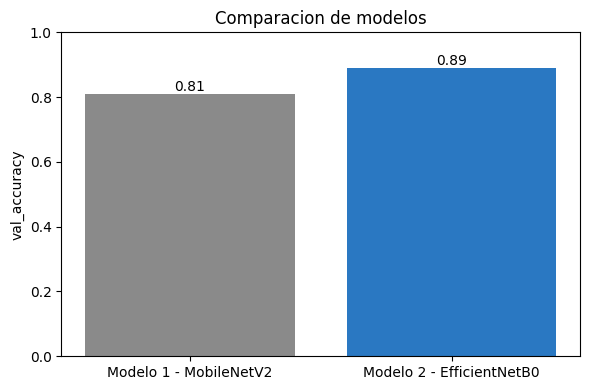

In [2]:
# ============================================================
# Comparacion de modelos (Avance 2)
# ============================================================
# Requisito: implementar al menos 2 versiones del modelo basadas en articulos del
# estado del arte, comparar sus resultados y que la 2da supere a la 1ra.
#   Modelo 1 - MobileNetV2    -> Sandler et al. (2018), CVPR, arXiv:1801.04381
#   Modelo 2 - EfficientNetB0 -> Tan & Le (2019),  ICML, arXiv:1905.11946
# val_accuracy = accuracy sobre el set de validacion (3,239 imagenes, 143 clases),
# tomada de la evaluacion de cada modelo en las celdas anteriores.

import pandas as pd
import matplotlib.pyplot as plt

resultados = {
    'Modelo 1 - MobileNetV2':    {'backbone': 'MobileNetV2',    'val_accuracy': 0.81,
                                  'referencia': 'Sandler et al. (2018), CVPR'},
    'Modelo 2 - EfficientNetB0': {'backbone': 'EfficientNetB0', 'val_accuracy': 0.89,
                                  'referencia': 'Tan & Le (2019), ICML'},
}

tabla = pd.DataFrame(resultados).T.reset_index().rename(columns={'index': 'modelo'})
print(tabla[['modelo', 'backbone', 'val_accuracy', 'referencia']].to_string(index=False))

accs = [resultados[m]['val_accuracy'] for m in resultados]
plt.figure(figsize=(6, 4))
barras = plt.bar(list(resultados), accs, color=['#8a8a8a', '#2a78c2'])
for b, a in zip(barras, accs):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.01, f'{a:.2f}', ha='center')
plt.ylabel('val_accuracy')
plt.ylim(0, 1)
plt.title('Comparacion de modelos')
plt.tight_layout()
plt.show()